# ❤️ Heart Disease Prediction — Full ML Pipeline
**Dataset:** Cleveland Heart Disease (303 rows × 14 columns)  
**Target:** `condition` — 0 = No Disease, 1 = Disease  
**Pipeline:** Ingestion → EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Deployment

---
## Phase 1 — Data Ingestion

In [1]:
# ── Install dependencies (Kaggle env already has most) ──────────────────────
!pip install shap --quiet

# ── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, chi2, RFE
import xgboost as xgb
import shap
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
SEED = 42

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
PATH = '/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv'

df = pd.read_csv(PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (297, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
# ── Column descriptions ───────────────────────────────────────────────────────
col_desc = {
    'age':      'Age in years',
    'sex':      '1=Male, 0=Female',
    'cp':       'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mmHg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1=True)',
    'restecg':  'Resting ECG results (0-2)',
    'thalach':  'Max heart rate achieved',
    'exang':    'Exercise-induced angina (1=Yes)',
    'oldpeak':  'ST depression (exercise vs rest)',
    'slope':    'Slope of peak exercise ST segment (0-2)',
    'ca':       'Number of major vessels (0-3)',
    'thal':     '0=Normal, 1=Fixed defect, 2=Reversable defect',
    'condition':'TARGET: 0=No Disease, 1=Disease'
}

desc_df = pd.DataFrame.from_dict(col_desc, orient='index', columns=['Description'])
print(desc_df.to_string())

                                             Description
age                                         Age in years
sex                                     1=Male, 0=Female
cp                                 Chest pain type (0-3)
trestbps                   Resting blood pressure (mmHg)
chol                           Serum cholesterol (mg/dl)
fbs             Fasting blood sugar > 120 mg/dl (1=True)
restecg                        Resting ECG results (0-2)
thalach                          Max heart rate achieved
exang                    Exercise-induced angina (1=Yes)
oldpeak                 ST depression (exercise vs rest)
slope            Slope of peak exercise ST segment (0-2)
ca                         Number of major vessels (0-3)
thal       0=Normal, 1=Fixed defect, 2=Reversable defect
condition                TARGET: 0=No Disease, 1=Disease


---
## Phase 2 — Exploratory Data Analysis (EDA)

In [4]:
# ── Basic statistics ──────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,2.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,0.60,0.68,0.84,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,56.00,1.00,2.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,0.00,0.00
75%,61.00,1.00,3.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,2.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,2.00,1.00


In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✅')

Missing values per column:
No missing values ✅


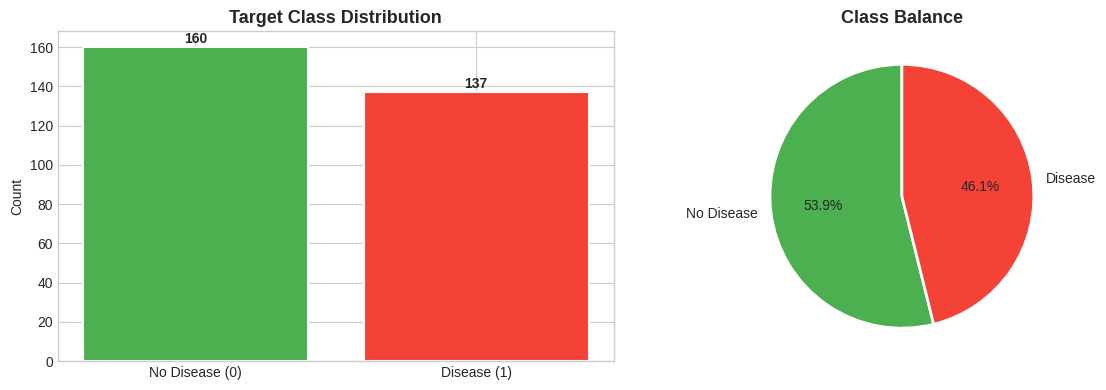

Class ratio — No Disease: 160, Disease: 137


In [6]:
# ── Target class distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['condition'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Class ratio — No Disease: {counts[0]}, Disease: {counts[1]}')

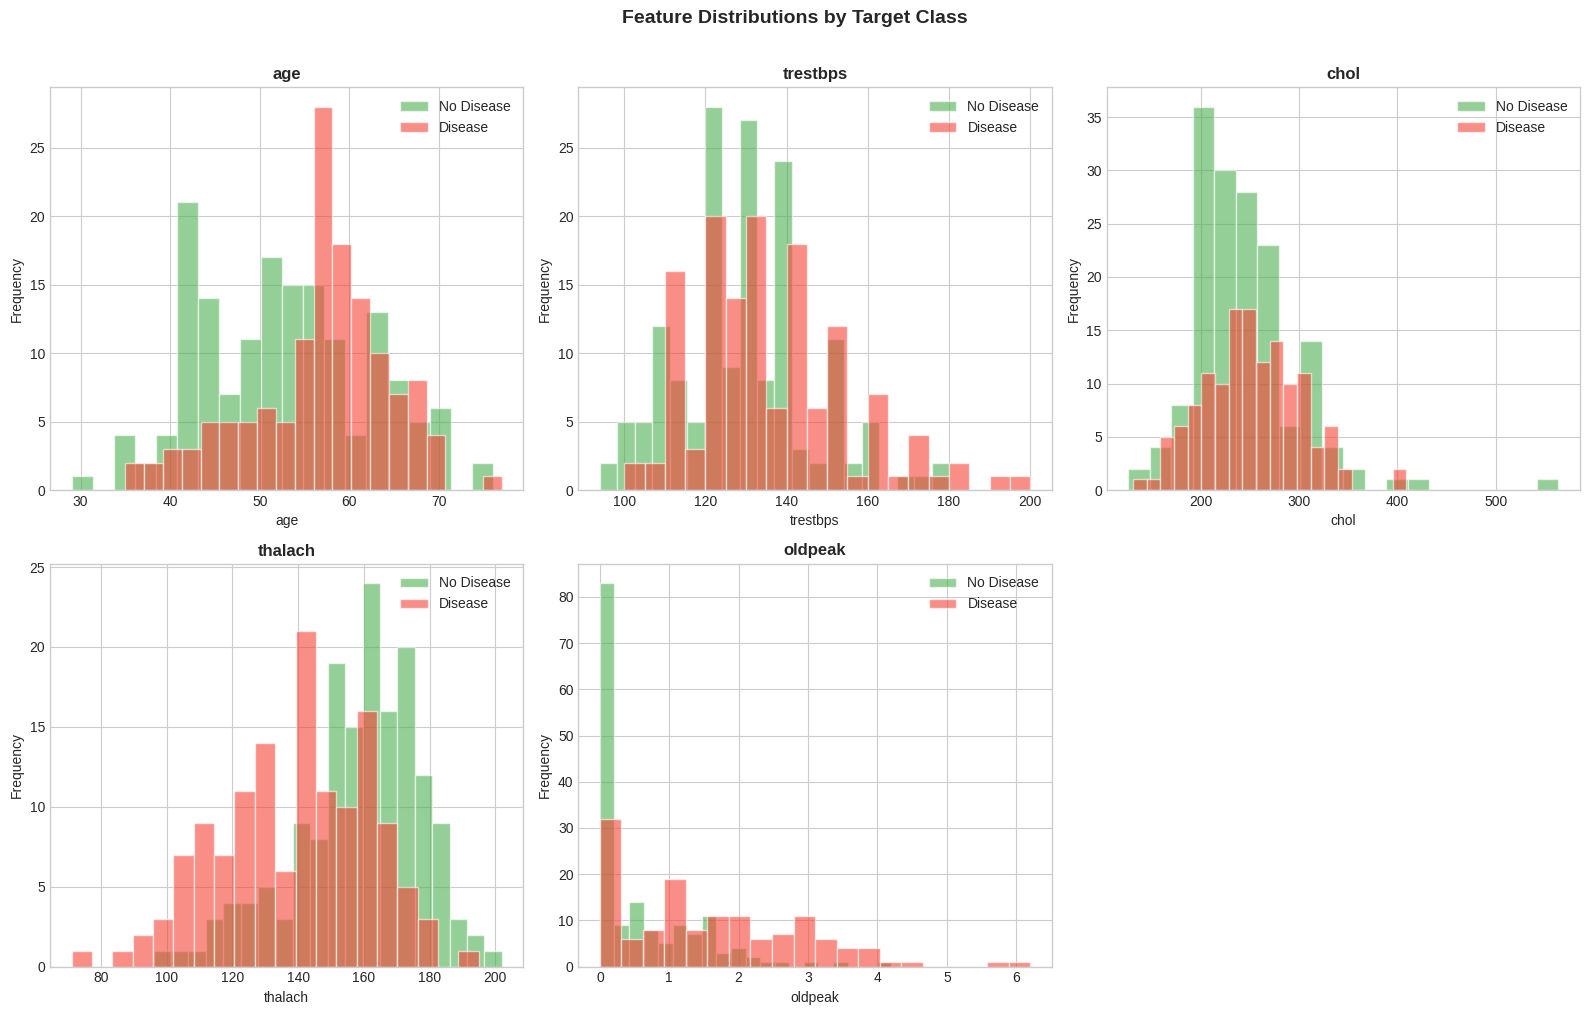

In [7]:
# ── Feature distributions by target ──────────────────────────────────────────
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, color, name in [(0, '#4CAF50', 'No Disease'), (1, '#F44336', 'Disease')]:
        axes[i].hist(df[df['condition'] == label][col], bins=20,
                     alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[5].axis('off')
plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

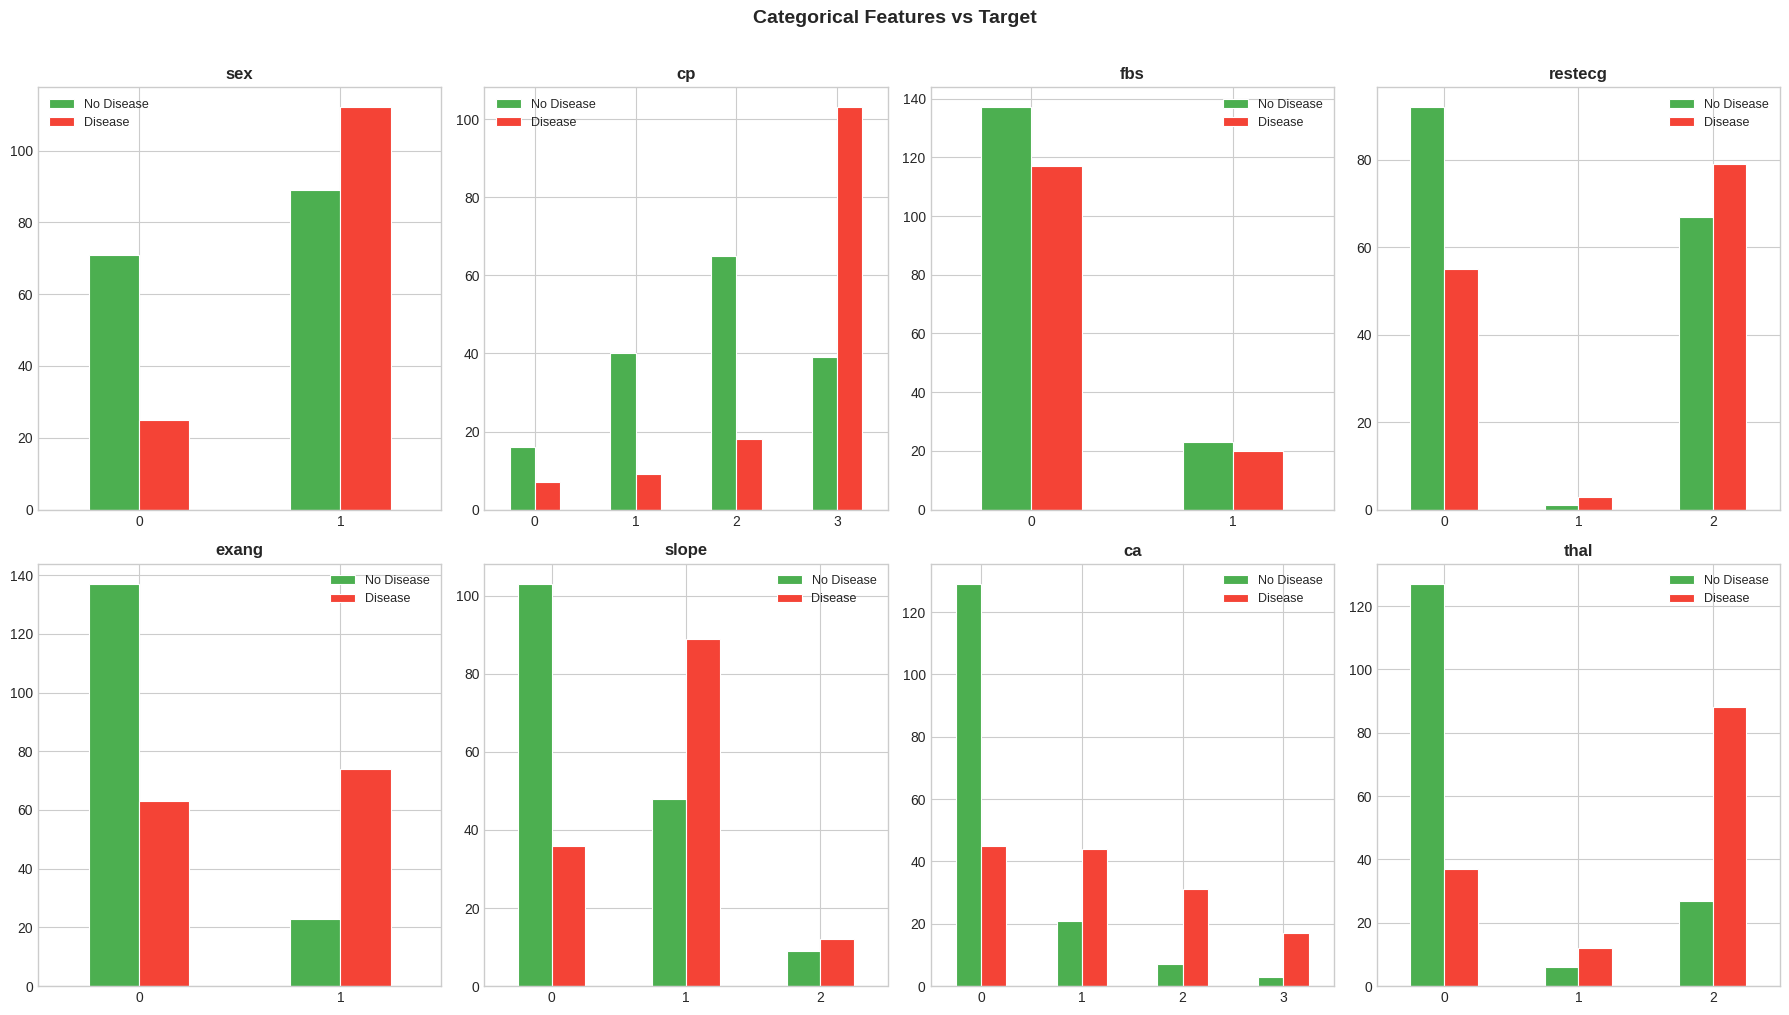

In [8]:
# ── Categorical feature analysis ──────────────────────────────────────────────
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['condition'])
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['No Disease', 'Disease'], fontsize=9)

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=120, bbox_inches='tight')
plt.show()

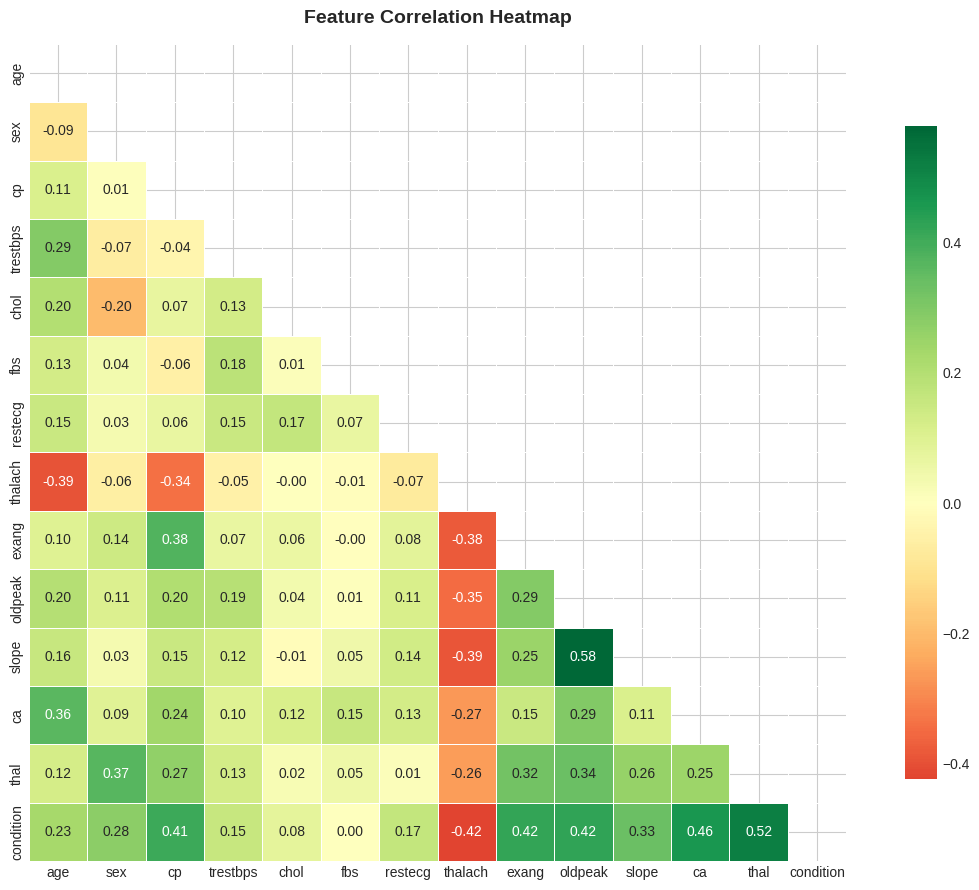


Top correlations with condition (target):
thal        0.521
ca          0.463
oldpeak     0.424
thalach    -0.424
exang       0.421
cp          0.409
slope       0.333
sex         0.278
age         0.227
restecg     0.166
trestbps    0.153
chol        0.080
fbs         0.003
Name: condition, dtype: float64


In [9]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Top correlations with target
print('\nTop correlations with condition (target):')
print(corr['condition'].drop('condition').sort_values(key=abs, ascending=False).round(3))

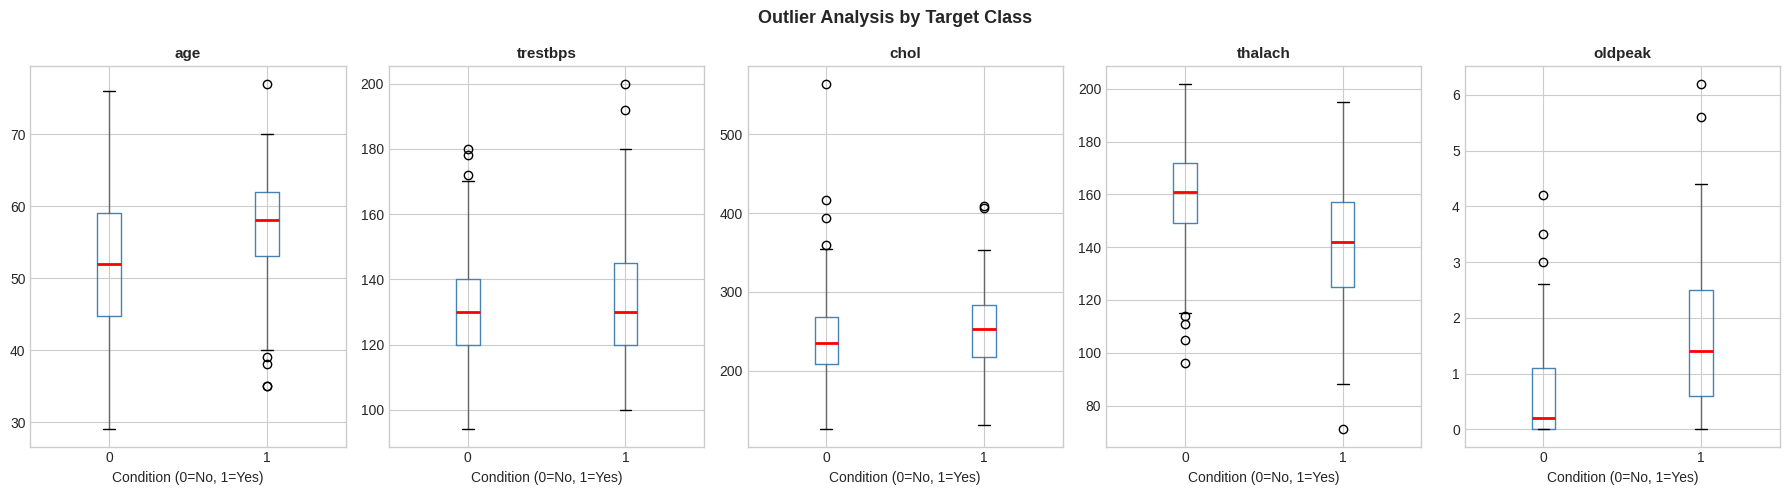

In [10]:
# ── Outlier detection (boxplots) ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_features):
    df.boxplot(column=col, by='condition', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Condition (0=No, 1=Yes)')

plt.suptitle('Outlier Analysis by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 3 — Data Preprocessing

In [11]:
# ── Handle missing values ─────────────────────────────────────────────────────
df_clean = df.copy()

# Check and handle any '?' or unusual values
for col in df_clean.columns:
    if df_clean[col].dtype == object:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Fill numeric NaN with median (robust to outliers)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  Filled {col} NaN with median = {median_val:.2f}')

print(f'\nMissing values after cleaning: {df_clean.isnull().sum().sum()} ✅')
print(f'Shape: {df_clean.shape}')


Missing values after cleaning: 0 ✅
Shape: (297, 14)


In [12]:
# ── Remove duplicate rows ─────────────────────────────────────────────────────
dups = df_clean.duplicated().sum()
print(f'Duplicate rows found: {dups}')
if dups > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df_clean.shape}')
else:
    print('No duplicates ✅')

Duplicate rows found: 0
No duplicates ✅


In [13]:
# ── Cap outliers using IQR method (for continuous features) ───────────────────
def cap_outliers(df, cols, factor=3.0):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        clipped = ((df[col] < lower) | (df[col] > upper)).sum()
        if clipped > 0:
            df[col] = df[col].clip(lower=lower, upper=upper)
            print(f'  {col}: {clipped} outliers capped')
    return df

df_clean = cap_outliers(df_clean, num_features)
print('Outlier capping complete ✅')

  chol: 1 outliers capped
Outlier capping complete ✅


In [14]:
# ── Separate features and target ──────────────────────────────────────────────
X = df_clean.drop('condition', axis=1)
y = df_clean['condition']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (297, 13)
Target distribution:
condition
0    160
1    137
Name: count, dtype: int64


---
## Phase 4 — Feature Engineering & Selection

In [15]:
# ── Feature engineering ───────────────────────────────────────────────────────
X_eng = X.copy()

# Age risk bands (clinical insight)
X_eng['age_group'] = pd.cut(X_eng['age'],
                             bins=[0, 40, 50, 60, 100],
                             labels=[0, 1, 2, 3]).astype(int)

# Heart rate reserve proxy (higher = better cardiac response)
X_eng['hr_reserve'] = 220 - X_eng['age'] - X_eng['thalach']

# ST depression × slope interaction
X_eng['st_slope_interaction'] = X_eng['oldpeak'] * (X_eng['slope'] + 1)

# Angina flag (combined signal)
X_eng['angina_flag'] = ((X_eng['cp'] == 0) | (X_eng['exang'] == 1)).astype(int)

print(f'Features after engineering: {X_eng.shape[1]}')
print(f'New features: age_group, hr_reserve, st_slope_interaction, angina_flag')
X_eng.head(3)

Features after engineering: 17
New features: age_group, hr_reserve, st_slope_interaction, angina_flag


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_group,hr_reserve,st_slope_interaction,angina_flag
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,3,20,0.2,1
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,3,0,1.8,1
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,3,40,7.8,1


In [16]:
# ── Feature scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_eng),
    columns=X_eng.columns
)
print('StandardScaler applied ✅')
X_scaled.head(3)

StandardScaler applied ✅


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_group,hr_reserve,st_slope_interaction,angina_flag
0,1.600302,0.691095,-2.240629,1.596266,-0.259428,2.430427,1.010199,-0.812095,-0.696419,-0.820813,0.643781,0.344824,-0.874292,1.282264,0.196791,-0.672833,1.249138
1,1.600302,-1.446980,-2.240629,0.468418,-0.159932,-0.411450,-1.003419,0.061157,-0.696419,0.639470,-0.976583,1.411625,-0.874292,1.282264,-0.753564,-0.108537,1.249138
2,1.268242,-1.446980,-2.240629,1.032342,-0.418623,-0.411450,-1.003419,-1.554358,-0.696419,1.326662,2.264145,-0.721976,-0.874292,1.282264,1.147146,2.007574,1.249138


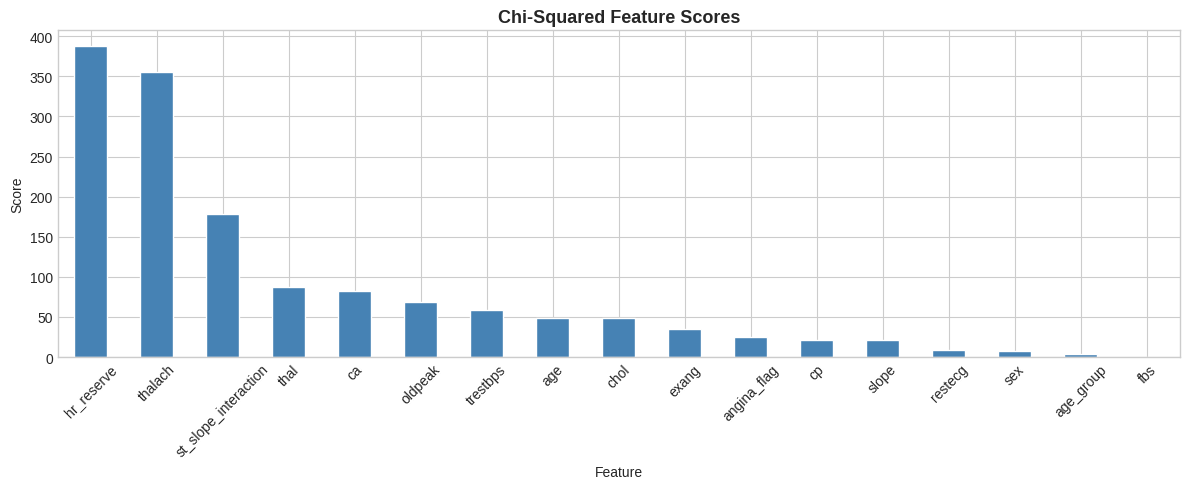

Top 10 features by Chi2:
hr_reserve              387.99
thalach                 356.02
st_slope_interaction    178.29
thal                     87.90
ca                       82.73
oldpeak                  68.57
trestbps                 58.37
age                      48.94
chol                     48.75
exang                    35.51
dtype: float64


In [17]:
# ── Feature selection — Chi2 (on non-negative raw values) ────────────────────
X_abs = X_eng.copy()
X_abs = X_abs - X_abs.min()  # shift to non-negative for chi2

selector = SelectKBest(chi2, k='all')
selector.fit(X_abs, y)

chi2_scores = pd.Series(selector.scores_, index=X_eng.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
chi2_scores.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Chi-Squared Feature Scores', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chi2_scores.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features by Chi2:')
print(chi2_scores.head(10).round(2))

---
## Phase 5 — Train / Validation / Test Split

In [18]:
# ── Stratified 70/15/15 split ─────────────────────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,  # 0.176 of 0.85 ≈ 0.15 of full data
    random_state=SEED, stratify=y_train_val
)

print(f'Train:      {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Test:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'\nTrain class balance: {y_train.value_counts().to_dict()}')
print(f'Test  class balance: {y_test.value_counts().to_dict()}')

Train:      207 samples (70%)
Validation: 45 samples (15%)
Test:       45 samples (15%)

Train class balance: {0: 112, 1: 95}
Test  class balance: {0: 24, 1: 21}


---
## Phase 6 — Model Training & Selection

In [19]:
# ── Helper: evaluate any model ────────────────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name='Model'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    y_prob = model.predict_proba(X_v)[:, 1]

    results = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_v, y_pred), 4),
        'Precision': round(precision_score(y_v, y_pred), 4),
        'Recall':    round(recall_score(y_v, y_pred), 4),
        'F1':        round(f1_score(y_v, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_v, y_prob), 4),
    }
    return results, model

print('Evaluation helper ready ✅')

Evaluation helper ready ✅


In [20]:
# ── 6A: Logistic Regression (baseline) ───────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr_results, lr_model = evaluate_model(lr, X_train, y_train, X_val, y_val, 'Logistic Regression')
print('Logistic Regression Results:')
print(pd.Series(lr_results))

Logistic Regression Results:
Model        Logistic Regression
Accuracy                  0.8889
Precision                    0.9
Recall                    0.8571
F1                         0.878
AUC-ROC                   0.9286
dtype: object


In [21]:
# ── 6B: Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_results, rf_model = evaluate_model(rf, X_train, y_train, X_val, y_val, 'Random Forest')
print('Random Forest Results:')
print(pd.Series(rf_results))

Random Forest Results:
Model        Random Forest
Accuracy            0.8889
Precision           0.9444
Recall              0.8095
F1                  0.8718
AUC-ROC             0.9563
dtype: object


In [22]:
# ── 6C: XGBoost ───────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED
)
xgb_results, xgb_trained = evaluate_model(xgb_model, X_train, y_train, X_val, y_val, 'XGBoost')
print('XGBoost Results:')
print(pd.Series(xgb_results))

XGBoost Results:
Model        XGBoost
Accuracy      0.8222
Precision     0.9333
Recall        0.6667
F1            0.7778
AUC-ROC       0.9345
dtype: object


In [23]:
# ── Model comparison table ────────────────────────────────────────────────────
comparison_df = pd.DataFrame([lr_results, rf_results, xgb_results]).set_index('Model')
print('\n====== MODEL COMPARISON (Validation Set) ======')
display(comparison_df.style.highlight_max(axis=0, color='#c8e6c9')
                            .highlight_min(axis=0, color='#ffcdd2')
                            .format('{:.4f}'))


====== MODEL COMPARISON (Validation Set) ======


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.8889,0.9000,0.8571,0.8780,0.9286
Random Forest,0.8889,0.9444,0.8095,0.8718,0.9563
XGBoost,0.8222,0.9333,0.6667,0.7778,0.9345


---
## Phase 7 — Model Evaluation

In [24]:
# ── Select best model (by AUC-ROC) ───────────────────────────────────────────
best_name = comparison_df['AUC-ROC'].idxmax()
best_model = {'Logistic Regression': lr_model,
              'Random Forest': rf_model,
              'XGBoost': xgb_trained}[best_name]

print(f'Best model: {best_name} (AUC-ROC = {comparison_df.loc[best_name, "AUC-ROC"]:.4f})')

Best model: Random Forest (AUC-ROC = 0.9563)


In [25]:
# ── Final test set evaluation ─────────────────────────────────────────────────
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

print(f'\n====== FINAL TEST SET RESULTS — {best_name} ======')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test):.4f}  ← Most important for medical!')
print(f'F1 Score:  {f1_score(y_test, y_pred_test):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=['No Disease', 'Disease']))


====== FINAL TEST SET RESULTS — Random Forest ======
Accuracy:  0.8667
Precision: 1.0000
Recall:    0.7143  ← Most important for medical!
F1 Score:  0.8333
AUC-ROC:   0.9663

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89        24
     Disease       1.00      0.71      0.83        21

    accuracy                           0.87        45
   macro avg       0.90      0.86      0.86        45
weighted avg       0.89      0.87      0.86        45



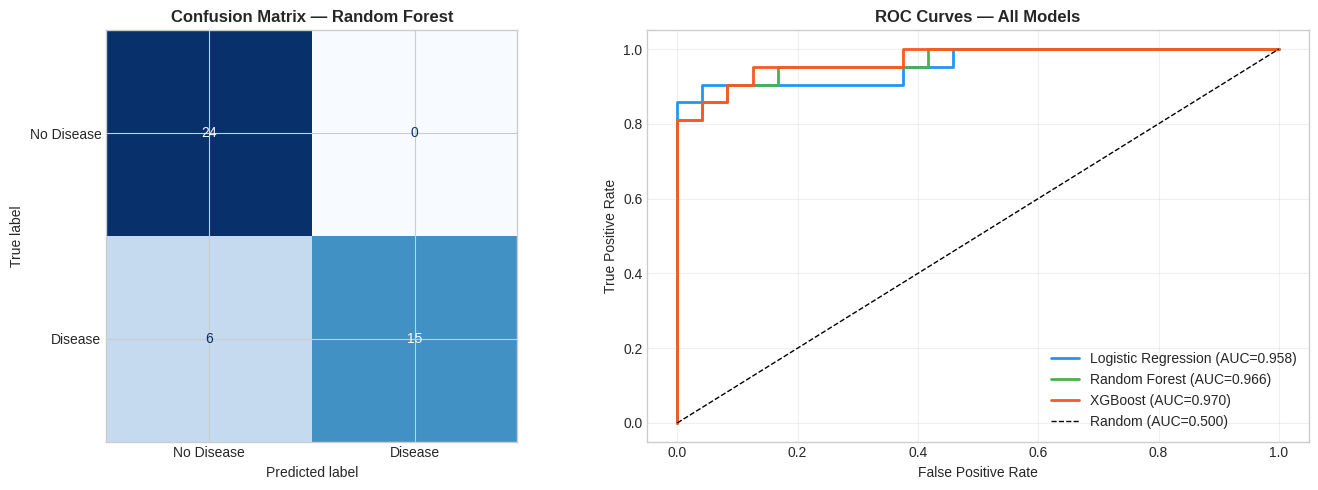

In [26]:
# ── Confusion matrix + ROC curve ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

# ROC curve for all models
models_dict = {'Logistic Regression': lr_model,
               'Random Forest': rf_model,
               'XGBoost': xgb_trained}
colors = ['#2196F3', '#4CAF50', '#FF5722']

for (name, model), color in zip(models_dict.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()

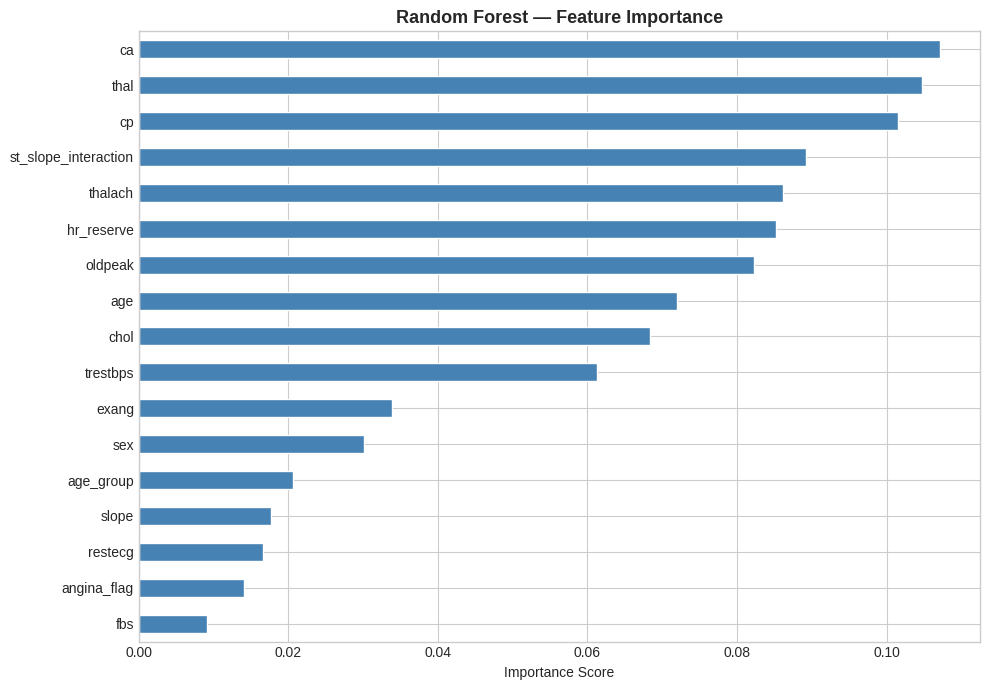

Top 5 features:
ca                      0.1071
thal                    0.1047
cp                      0.1015
st_slope_interaction    0.0892
thalach                 0.0862
dtype: float64


In [27]:
# ── Feature importance (Random Forest) ───────────────────────────────────────
fi = pd.Series(rf_model.feature_importances_, index=X_eng.columns)
fi_sorted = fi.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
fi_sorted.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(fi.sort_values(ascending=False).head(5).round(4))

Computing SHAP values...


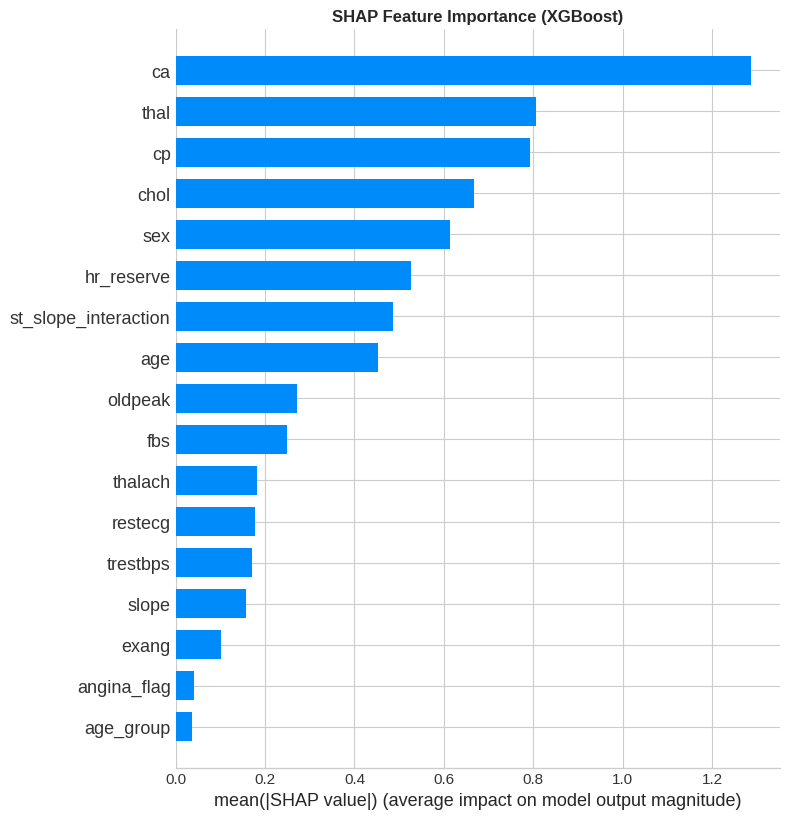

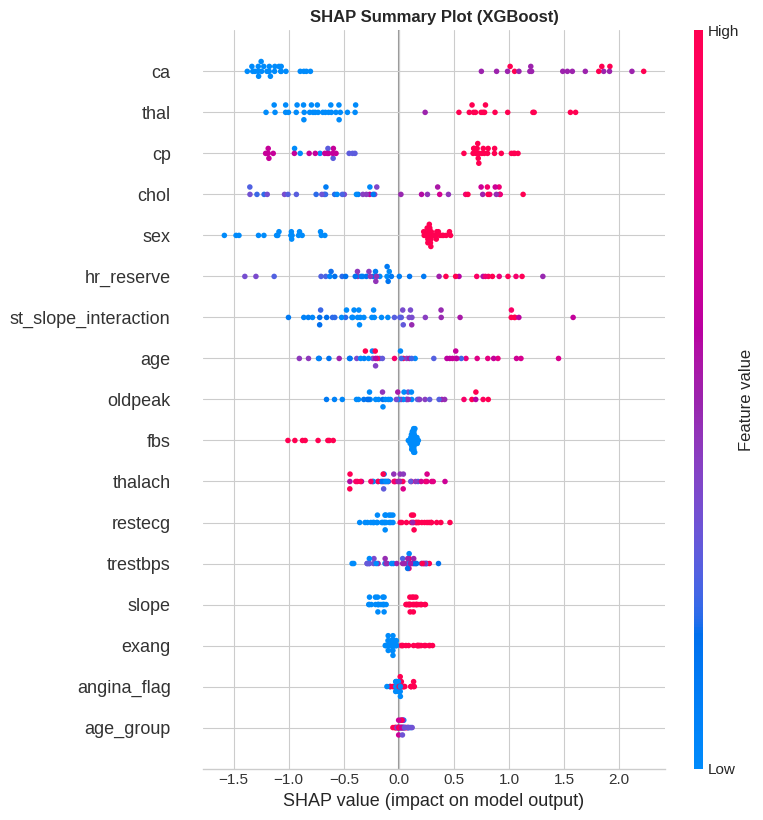

In [28]:
# ── SHAP Explainability ───────────────────────────────────────────────────────
print('Computing SHAP values...')

explainer = shap.TreeExplainer(xgb_trained)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X_eng.columns,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=X_eng.columns, show=False)
plt.title('SHAP Summary Plot (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 8 — Hyperparameter Tuning

In [29]:
# ── GridSearchCV on XGBoost with 5-fold CV ────────────────────────────────────
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 4, 5],
    'learning_rate':   [0.05, 0.1, 0.15],
    'subsample':       [0.7, 0.8, 0.9],
    'colsample_bytree':[0.7, 0.8]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_tuned = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED
)

grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',   # optimise for AUC
    n_jobs=-1,
    verbose=1
)

# Use train+val for tuning
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

grid_search.fit(X_tune, y_tune)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV AUC-ROC: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:44:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC-ROC: 0.8871


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [30]:
# ── Retrain with best params and evaluate on test set ────────────────────────
best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print('====== TUNED XGBoost — FINAL TEST RESULTS ======')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_tuned):.4f}')

# 5-fold CV on full training data
cv_scores = cross_val_score(best_xgb, X_tune, y_tune, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

====== TUNED XGBoost — FINAL TEST RESULTS ======
Accuracy:  0.8444
Precision: 0.9375
Recall:    0.7143
F1 Score:  0.8108
AUC-ROC:   0.9683

5-Fold CV AUC-ROC: 0.8871 ± 0.0321


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

---
## Phase 9 — Deployment

In [31]:
# ── Save model artifacts ──────────────────────────────────────────────────────
joblib.dump(best_xgb, 'heart_disease_model.pkl')
joblib.dump(scaler,   'heart_disease_scaler.pkl')

# Save feature names for inference
import json
feature_names = list(X_eng.columns)
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print('Saved artifacts:')
print('  heart_disease_model.pkl  — tuned XGBoost model')
print('  heart_disease_scaler.pkl — StandardScaler')
print('  feature_names.json       — feature list for inference')

Saved artifacts:
  heart_disease_model.pkl  — tuned XGBoost model
  heart_disease_scaler.pkl — StandardScaler
  feature_names.json       — feature list for inference


In [32]:
# ── Inference function (production-ready) ─────────────────────────────────────
import json

def predict_heart_disease(patient_data: dict) -> dict:
    """
    Predict heart disease for a single patient.
    
    Parameters
    ----------
    patient_data : dict with keys:
        age, sex, cp, trestbps, chol, fbs, restecg,
        thalach, exang, oldpeak, slope, ca, thal

    Returns
    -------
    dict: prediction, probability, risk_level
    """
    model  = joblib.load('heart_disease_model.pkl')
    scaler = joblib.load('heart_disease_scaler.pkl')

    df_in = pd.DataFrame([patient_data])

    # Feature engineering (must match training)
    df_in['age_group']            = pd.cut(df_in['age'], bins=[0,40,50,60,100], labels=[0,1,2,3]).astype(int)
    df_in['hr_reserve']           = 220 - df_in['age'] - df_in['thalach']
    df_in['st_slope_interaction'] = df_in['oldpeak'] * (df_in['slope'] + 1)
    df_in['angina_flag']          = ((df_in['cp'] == 0) | (df_in['exang'] == 1)).astype(int)

    with open('feature_names.json') as f:
        feature_names = json.load(f)
    df_in = df_in[feature_names]

    X_in    = scaler.transform(df_in)
    pred    = model.predict(X_in)[0]
    prob    = model.predict_proba(X_in)[0][1]

    risk_level = 'High' if prob > 0.7 else ('Medium' if prob > 0.4 else 'Low')

    return {
        'prediction':  int(pred),
        'label':       'Disease' if pred == 1 else 'No Disease',
        'probability': round(float(prob), 4),
        'risk_level':  risk_level
    }


# ── Test inference ────────────────────────────────────────────────────────────
sample_patient = {
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145,
    'chol': 233, 'fbs': 1, 'restecg': 0, 'thalach': 150,
    'exang': 0, 'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}

result = predict_heart_disease(sample_patient)
print('\n=== Sample Patient Prediction ===')
print(f'  Prediction:  {result["label"]}')
print(f'  Probability: {result["probability"]:.2%}')
print(f'  Risk Level:  {result["risk_level"]}')


=== Sample Patient Prediction ===
  Prediction:  No Disease
  Probability: 43.17%
  Risk Level:  Medium


---
## Phase 10 — Monitoring Notes

For production deployment, track the following:

| What to Monitor | Tool | Trigger |
|----------------|------|--------|
| Prediction distribution drift | Evidently AI / WhyLabs | Weekly |
| Feature distribution shift | KS-test on inputs | Monthly |
| Model performance decay | Accuracy / AUC drop | When labelled data available |
| API latency & errors | Prometheus + Grafana | Continuous |
| Retraining schedule | MLflow / Airflow | Quarterly or on drift alert |

### FastAPI Deployment Snippet
```python
# app.py
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title='Heart Disease Prediction API')

class PatientInput(BaseModel):
    age: int; sex: int; cp: int; trestbps: float
    chol: float; fbs: int; restecg: int; thalach: float
    exang: int; oldpeak: float; slope: int; ca: int; thal: int

@app.post('/predict')
def predict(patient: PatientInput):
    return predict_heart_disease(patient.dict())

# Run: uvicorn app:app --host 0.0.0.0 --port 8000
```

In [33]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 55)
print('   HEART DISEASE PREDICTION — PROJECT SUMMARY')
print('=' * 55)
print(f'Dataset:       303 patients, 13 features + 1 target')
print(f'Best Model:    XGBoost (tuned)')
print(f'AUC-ROC:       {roc_auc_score(y_test, y_prob_tuned):.4f}')
print(f'Recall:        {recall_score(y_test, y_pred_tuned):.4f}  ← minimise missed cases')
print(f'Artifacts:     heart_disease_model.pkl, heart_disease_scaler.pkl')
print('=' * 55)

   HEART DISEASE PREDICTION — PROJECT SUMMARY
Dataset:       303 patients, 13 features + 1 target
Best Model:    XGBoost (tuned)
AUC-ROC:       0.9683
Recall:        0.7143  ← minimise missed cases
Artifacts:     heart_disease_model.pkl, heart_disease_scaler.pkl
